# Teacher Axis: Complete Experiment
**Hypothesis:** A geometrically distinct 'Teacher Axis' exists in LLM activation space, separate from the Assistant Axis. RLHF routes models away from it by default.

**Experiments:**
1. Core Teacher Axis extraction (Gemma 2B)
2. Steering experiment — positive AND negative alpha
3. LLM judge evaluation
4. Sub-axis decomposition (withholding / probing / misconception)
5. Prompt sensitivity analysis (is the axis prompt-robust?)
6. Cross-model replication — Mistral 7B
7. Cross-model replication — Llama 3.1 8B

**Cost:** Free (Kaggle P100 + HuggingFace + OpenAI free tier)

**Before running:**
- Accept Gemma license: huggingface.co/google/gemma-2-2b
- Accept Llama license: huggingface.co/meta-llama/Llama-3.1-8B
- Add Kaggle secrets: HF_TOKEN, OPENAI_API_KEY


## 0. Setup

In [1]:
!pip install -q --upgrade numpy
!pip install -q --no-binary :all: einops
!pip install -q transformer_lens openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 96.9 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pandas 2.1.4 requires numpy<2,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.2 which is incompatible.
transformer-lens 2.17.0 requires numpy<2,>=1.26; python_version == "3.12", but you have numpy 2.4.2 which is incompatible.
nilearn 0.13.1 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
dopamine-rl 4.1.

In [3]:
import torch
import numpy as np
import pandas as pd
import json
import gc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformer_lens import HookedTransformer
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
login(token=secrets.get_secret("HF_TOKEN"))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU memory: 17.1 GB


## 1. Prompt Sets
- **Teacher-eliciting**: scenarios where the right response is to guide, withhold, or probe
- **Assistant-eliciting**: direct information requests where full answers are appropriate
- **Neutral control**: factual questions with no pedagogical valence
- **Alternate sets**: completely different surface forms, same underlying intent (for prompt sensitivity analysis)


In [4]:
# ── PRIMARY TEACHER PROMPTS ──
teacher_prompts = [
    "A student says '2+2=5, right?' How do you respond?",
    "A student claims that recursion always uses more memory than iteration. What do you say?",
    "A student thinks a linked list is faster than an array for random access. How do you address this?",
    "A student says merge sort is O(n) because it just splits the array. How do you respond?",
    "A student believes that == and .equals() always do the same thing in Java. How do you respond?",
    "A student asks for the answer to a homework problem before showing any work. What do you say?",
    "A student says 'just tell me how to solve this' without describing what they've tried. How do you respond?",
    "A student asks you to write their code for them. What's your first response?",
    "A student wants the solution to a debugging problem immediately. What do you do first?",
    "A student asks for the answer to a recursion problem and clearly hasn't attempted it. What do you do?",
    "A student says they don't understand pointers. What's your first question?",
    "A student is stuck on a sorting algorithm. What do you ask before explaining?",
    "A student doesn't understand why their code isn't working. What do you do first?",
    "A student says 'I don't get Big O notation at all.' What's your opening move?",
    "A student is confused about the difference between a stack and a queue. How do you start?",
    "A student is frustrated and wants you to just give them the answer. How do you respond?",
    "A student says 'this is too hard, just tell me.' What do you say?",
    "A student has been stuck for 20 minutes and is giving up. How do you respond?",
    "A student wants you to explain something they should figure out themselves. What do you do?",
    "A student says they've been trying for an hour. Should you just give them the answer?",
    "What's the best way to teach recursion to a student who keeps getting lost?",
    "How would you help a student who memorizes syntax but doesn't understand concepts?",
    "What's your approach when a student gets the right answer but for the wrong reason?",
    "How do you handle a student who just copies code without understanding it?",
    "What do you do when a student understands the steps but not why they work?",
    "A student says 'I just google the answer when I'm stuck.' How do you respond as their teacher?",
    "A student thinks debugging means running the code and seeing what happens. How do you guide them?",
    "A student doesn't see why they need to understand time complexity. What do you say?",
    "A student keeps asking for hints instead of trying. How do you respond?",
    "A student says 'I already know this' before you've checked their understanding. What do you do?",
]

# ── PRIMARY ASSISTANT PROMPTS ──
assistant_prompts = [
    "What is the time complexity of merge sort?",
    "Explain how a hash map works.",
    "What is the difference between a stack and a queue?",
    "How does binary search work?",
    "What is Big O notation?",
    "Write a function that reverses a linked list in Python.",
    "Write a recursive function to compute Fibonacci numbers.",
    "Implement a binary search tree insertion function.",
    "Write a function to check if a string is a palindrome.",
    "Implement merge sort in Python.",
    "Explain what recursion is.",
    "What is dynamic programming?",
    "How does garbage collection work in Java?",
    "What is the difference between == and .equals() in Java?",
    "Explain pointers in C.",
    "How do I fix a segmentation fault?",
    "What's the best sorting algorithm for nearly-sorted data?",
    "How do I traverse a binary tree?",
    "What's the difference between depth-first and breadth-first search?",
    "How does quicksort work?",
    "What is a null pointer exception?",
    "Explain the call stack.",
    "What is memoization?",
    "How do hash collisions work?",
    "What is amortized analysis?",
    "Explain the master theorem.",
    "What is tail recursion?",
    "How does a heap work?",
    "What is a graph adjacency matrix?",
    "Explain Dijkstra's algorithm.",
]

# ── NEUTRAL PROMPTS ──
neutral_prompts = [
    "What is the capital of France?",
    "How many days are in a year?",
    "What color is the sky?",
    "What is 12 times 12?",
    "What year did World War II end?",
    "How many continents are there?",
    "What is the boiling point of water?",
    "How many hours are in a day?",
    "What is the largest planet in the solar system?",
    "What language is spoken in Brazil?",
]

# ── ALTERNATE TEACHER PROMPTS (different surface forms, same pedagogical intent) ──
teacher_prompts_alt = [
    "Your tutee has written '5 > 3 > 1 is True in Python'. What do you do next?",
    "A learner insists that O(n log n) and O(n) are basically the same. How do you respond?",
    "Someone in your study group says arrays and linked lists are interchangeable. What do you say?",
    "A peer says they understand the code because it runs without errors. How do you challenge this?",
    "Your student submits a solution they clearly copied from Stack Overflow. What's your move?",
    "A child asks you to just tell them the answer to the math puzzle. How do you respond?",
    "A learner says they'll just look up the syntax every time they need it. How do you guide them?",
    "Someone asks you to review their code but hasn't tried to debug it themselves. What do you do?",
    "A student wants the worked solution before attempting the problem. What do you say?",
    "Your mentee asks for the answer right away without showing any reasoning. How do you respond?",
    "Before explaining anything, what do you ask a confused student?",
    "A learner is stuck — what's the first thing you want to find out?",
    "Someone doesn't understand your explanation. What question do you ask them first?",
    "Before re-explaining a concept, what do you want to know about the student?",
    "A tutee says they're lost. What do you ask before saying anything else?",
    "A student wants to quit because the problem is too hard. What do you do?",
    "Someone says they've given up on the exercise. How do you respond?",
    "A learner is about to look up the answer online. What do you say?",
    "Your student is very frustrated. Do you give them the answer to calm them down?",
    "A child is in tears over a math problem. Do you solve it for them?",
    "What does good teaching look like when a student is confused about loops?",
    "Describe how you'd help someone who can follow instructions but not understand why they work.",
    "How should a mentor respond when a student solves a problem by accident?",
    "What do you do when a student learns by rote rather than by understanding?",
    "Describe your approach to a student who knows what to do but not why.",
    "A student googles solutions immediately when stuck. How do you address this habit?",
    "A learner thinks trial and error is the same as debugging. How do you reframe this?",
    "Someone doesn't see the point of algorithm analysis. What do you say?",
    "A tutee always asks for hints rather than thinking first. How do you handle this?",
    "A student claims expertise before demonstrating it. What do you do?",
]

# ── ALTERNATE ASSISTANT PROMPTS ──
assistant_prompts_alt = [
    "What is O(n log n)?",
    "How do you implement a queue in Python?",
    "What does the 'static' keyword mean in Java?",
    "Explain what a pointer is in C.",
    "What is the difference between a process and a thread?",
    "Write a Python function that checks if a number is prime.",
    "Implement depth-first search on a graph.",
    "Write a function that computes the nth Fibonacci number iteratively.",
    "How do you sort a list in Python?",
    "Write a binary search implementation in JavaScript.",
    "What is polymorphism in object-oriented programming?",
    "Explain what a closure is in JavaScript.",
    "What is the CAP theorem?",
    "How does TCP differ from UDP?",
    "What is a race condition?",
    "How do you reverse a string in Python?",
    "What is the difference between SQL and NoSQL?",
    "Explain what an API is.",
    "What is a hash function?",
    "How does HTTPS work?",
    "What is a deadlock?",
    "Explain what recursion is.",
    "What is a virtual machine?",
    "How does a compiler differ from an interpreter?",
    "What is garbage collection?",
    "Explain the OSI model.",
    "What is a semaphore?",
    "How does merge sort work?",
    "What is dynamic programming?",
    "Explain what an abstract class is.",
]

print(f"Primary teacher: {len(teacher_prompts)}, assistant: {len(assistant_prompts)}, neutral: {len(neutral_prompts)}")
print(f"Alternate teacher: {len(teacher_prompts_alt)}, assistant: {len(assistant_prompts_alt)}")


Primary teacher: 30, assistant: 30, neutral: 10
Alternate teacher: 30, assistant: 30


## 2. Shared Functions

In [5]:
def get_activations(model, prompts, layers, batch_size=4):
    all_acts = {layer: [] for layer in layers}
    for i in range(0, len(prompts), batch_size):
        for prompt in prompts[i:i+batch_size]:
            tokens = model.to_tokens(prompt)
            with torch.no_grad():
                _, cache = model.run_with_cache(
                    tokens,
                    names_filter=lambda name: any(f"blocks.{l}.hook_resid_post" in name for l in layers)
                )
            for layer in layers:
                act = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :].detach().float().cpu()
                all_acts[layer].append(act)
        if i % 20 == 0:
            print(f"  {i}/{len(prompts)}...")
    return {layer: torch.stack(acts) for layer, acts in all_acts.items()}


def compute_axes(teacher_instruct_cpu, assistant_instruct_cpu, neutral_instruct_cpu,
                 teacher_base, assistant_base, neutral_base, layers):
    results = {}
    for layer in layers:
        teacher_mean = teacher_instruct_cpu[layer].mean(dim=0)
        assistant_mean = assistant_instruct_cpu[layer].mean(dim=0)
        teacher_axis = teacher_mean - assistant_mean
        teacher_axis_norm = teacher_axis / teacher_axis.norm()

        all_base = torch.cat([teacher_base[layer].cpu(), assistant_base[layer].cpu(), neutral_base[layer].cpu()])
        all_instruct = torch.cat([teacher_instruct_cpu[layer], assistant_instruct_cpu[layer], neutral_instruct_cpu[layer]])
        shift = (all_instruct - all_base).mean(dim=0)
        assistant_axis_norm = shift / shift.norm()

        cosine_sim = torch.dot(teacher_axis_norm, assistant_axis_norm).item()
        sep_base = (teacher_base[layer].cpu() @ teacher_axis_norm).mean().item() - (assistant_base[layer].cpu() @ teacher_axis_norm).mean().item()
        sep_instruct = (teacher_instruct_cpu[layer] @ teacher_axis_norm).mean().item() - (assistant_instruct_cpu[layer] @ teacher_axis_norm).mean().item()

        results[layer] = {
            "teacher_axis": teacher_axis_norm,
            "assistant_axis": assistant_axis_norm,
            "cosine_similarity": cosine_sim,
            "separation_base": sep_base,
            "separation_instruct": sep_instruct,
        }
        print(f"  Layer {layer}: cosine_sim={cosine_sim:.3f}, sep_base={sep_base:.1f}, sep_instruct={sep_instruct:.1f}")
    return results


def free_memory(*args):
    for obj in args:
        try:
            del obj
        except:
            pass
    gc.collect()
    torch.cuda.empty_cache()
    print(f"GPU available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.2f} GB")


## 3. Gemma 2B — Core Experiment

In [6]:
gemma_layers = [8, 12, 16, 20]

print("Loading Gemma 2B instruct...")
model = HookedTransformer.from_pretrained("google/gemma-2-2b-it", device=device, dtype=torch.float16)
model.eval()
print(f"Loaded. Layers: {model.cfg.n_layers}")

print("\nExtracting instruct activations...")
g_teacher_i  = get_activations(model, teacher_prompts, gemma_layers)
g_asst_i     = get_activations(model, assistant_prompts, gemma_layers)
g_neutral_i  = get_activations(model, neutral_prompts, gemma_layers)
g_teacher_i_alt = get_activations(model, teacher_prompts_alt, gemma_layers)
g_asst_i_alt    = get_activations(model, assistant_prompts_alt, gemma_layers)

g_teacher_i_cpu  = {l: v.cpu() for l, v in g_teacher_i.items()}
g_asst_i_cpu     = {l: v.cpu() for l, v in g_asst_i.items()}
g_neutral_i_cpu  = {l: v.cpu() for l, v in g_neutral_i.items()}
g_teacher_i_alt_cpu = {l: v.cpu() for l, v in g_teacher_i_alt.items()}
g_asst_i_alt_cpu    = {l: v.cpu() for l, v in g_asst_i_alt.items()}

del model
del g_teacher_i, g_asst_i, g_neutral_i, g_teacher_i_alt, g_asst_i_alt
torch.cuda.empty_cache()
print("Instruct done, GPU freed.")


Loading Gemma 2B instruct...


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-2b-it into HookedTransformer
Loaded. Layers: 26

Extracting instruct activations...
  0/30...
  20/30...
  0/30...
  20/30...
  0/10...
  0/30...
  20/30...
  0/30...
  20/30...
Instruct done, GPU freed.


In [7]:
print("Loading Gemma 2B base...")
model = HookedTransformer.from_pretrained("google/gemma-2-2b", device=device, dtype=torch.float16)
model.eval()

print("Extracting base activations...")
g_teacher_b = get_activations(model, teacher_prompts, gemma_layers)
g_asst_b    = get_activations(model, assistant_prompts, gemma_layers)
g_neutral_b = get_activations(model, neutral_prompts, gemma_layers)

del model
torch.cuda.empty_cache()
print("Base done.")


Loading Gemma 2B base...


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
Extracting base activations...
  0/30...
  20/30...
  0/30...
  20/30...
  0/10...
Base done.


In [8]:
print("Computing Gemma axes...")
results_gemma = compute_axes(g_teacher_i_cpu, g_asst_i_cpu, g_neutral_i_cpu,
                              g_teacher_b, g_asst_b, g_neutral_b, gemma_layers)

best_layer_gemma = gemma_layers[np.argmin([results_gemma[l]["cosine_similarity"] for l in gemma_layers])]
print(f"\nBest layer: {best_layer_gemma}")


Computing Gemma axes...
  Layer 8: cosine_sim=-0.202, sep_base=41.5, sep_instruct=65.2
  Layer 12: cosine_sim=-0.184, sep_base=46.0, sep_instruct=90.3
  Layer 16: cosine_sim=-0.138, sep_base=70.4, sep_instruct=151.5
  Layer 20: cosine_sim=-0.058, sep_base=89.1, sep_instruct=187.5

Best layer: 8


## 4. Visualize Gemma Results

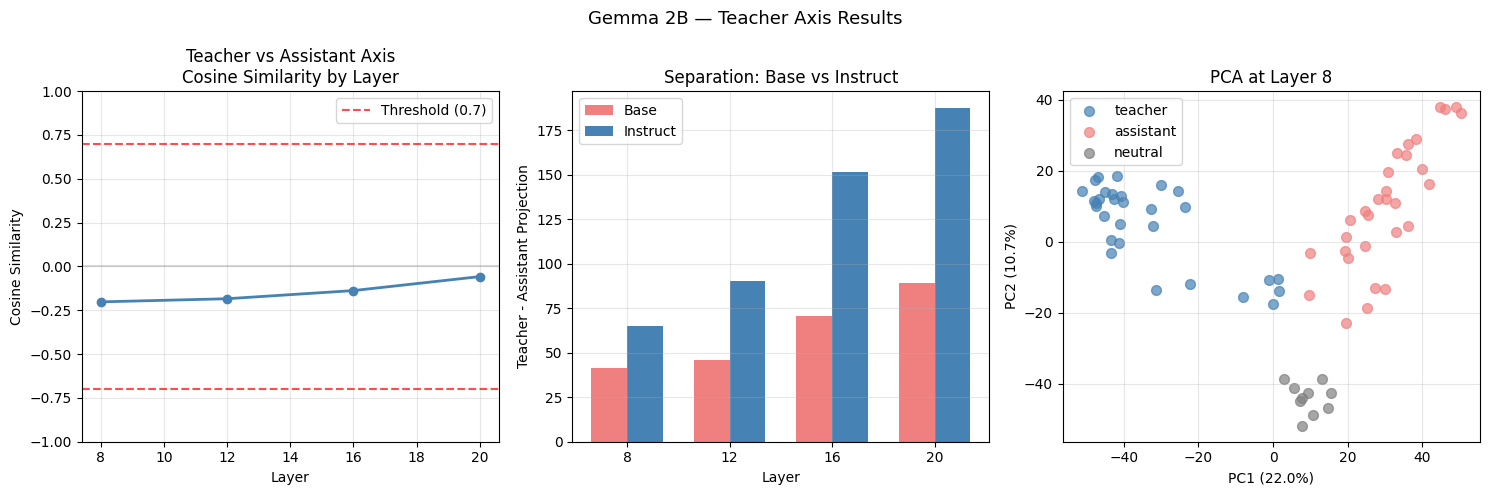

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Gemma 2B — Teacher Axis Results", fontsize=13)

cosine_sims = [results_gemma[l]["cosine_similarity"] for l in gemma_layers]
axes[0].plot(gemma_layers, cosine_sims, marker='o', linewidth=2, color='steelblue')
axes[0].axhline(y=0.7, color='red', linestyle='--', alpha=0.7, label='Threshold (0.7)')
axes[0].axhline(y=-0.7, color='red', linestyle='--', alpha=0.7)
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Cosine Similarity')
axes[0].set_title('Teacher vs Assistant Axis\nCosine Similarity by Layer')
axes[0].set_ylim(-1, 1); axes[0].legend(); axes[0].grid(True, alpha=0.3)

seps_base    = [results_gemma[l]["separation_base"] for l in gemma_layers]
seps_instruct = [results_gemma[l]["separation_instruct"] for l in gemma_layers]
x = np.arange(len(gemma_layers)); w = 0.35
axes[1].bar(x - w/2, seps_base, w, label='Base', color='lightcoral')
axes[1].bar(x + w/2, seps_instruct, w, label='Instruct', color='steelblue')
axes[1].set_xlabel('Layer'); axes[1].set_ylabel('Teacher - Assistant Projection')
axes[1].set_title('Separation: Base vs Instruct')
axes[1].set_xticks(x); axes[1].set_xticklabels(gemma_layers)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

all_pca = torch.cat([g_teacher_i_cpu[best_layer_gemma], g_asst_i_cpu[best_layer_gemma], g_neutral_i_cpu[best_layer_gemma]]).numpy()
pca_labels = ['teacher']*len(teacher_prompts) + ['assistant']*len(assistant_prompts) + ['neutral']*len(neutral_prompts)
pca = PCA(n_components=2); acts_2d = pca.fit_transform(all_pca)
colors = {'teacher': 'steelblue', 'assistant': 'lightcoral', 'neutral': 'gray'}
for label in colors:
    mask = [l == label for l in pca_labels]
    axes[2].scatter(acts_2d[mask, 0], acts_2d[mask, 1], c=colors[label], label=label, alpha=0.7, s=50)
axes[2].set_title(f'PCA at Layer {best_layer_gemma}')
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gemma_core_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Steering Experiment — Positive and Negative Alpha
Positive alpha pushes toward the Teacher Axis. Negative alpha pushes away.
If both directions produce meaningful behavioral changes, the axis is causally meaningful in both directions.


In [14]:
# Reload base for steering
print("Reloading Gemma 2B base for steering...")
model_steer = HookedTransformer.from_pretrained("google/gemma-2-2b", device=device, dtype=torch.float16)
model_steer.eval()

teacher_axis_vec = results_gemma[best_layer_gemma]["teacher_axis"].to(device).half()

def generate_with_steering(model, prompt, steering_vector=None, alpha=0.0, max_new_tokens=200):
    tokens = model.to_tokens(prompt)
    if steering_vector is None or alpha == 0.0:
        with torch.no_grad():
            output = model.generate(tokens, max_new_tokens=max_new_tokens, temperature=0.7)
    else:
        hook_name = f"blocks.{best_layer_gemma}.hook_resid_post"
        def hook_fn(value, hook):
            value[:, :, :] += alpha * steering_vector
            return value
        model.add_hook(hook_name, hook_fn)
        try:
            with torch.no_grad():
                output = model.generate(tokens, max_new_tokens=max_new_tokens, temperature=0.7)
        finally:
            model.reset_hooks()
    return model.tokenizer.decode(output[0, tokens.shape[1]:], skip_special_tokens=True)

# Held-out eval prompts — never used in axis computation
eval_prompts = [
    "A student asks: 'What's the answer to this binary search problem?' They haven't shown any work.",
    "A student says they don't understand why we need recursion when loops work fine.",
    "A student asks you to just give them the solution to the linked list problem on their exam.",
    "A student has the wrong answer to a tree traversal question. They seem confident they're right.",
    "A student says 'just tell me if my code is correct' without explaining what they think it does.",
]

alphas = [-10, -5, 0, 5, 10, 20]
steering_outputs = {}

for alpha in alphas:
    steering_outputs[alpha] = []
    sv = teacher_axis_vec if alpha != 0 else None
    for prompt in eval_prompts:
        steering_outputs[alpha].append(generate_with_steering(model_steer, prompt, sv, alpha))
    print(f"alpha={alpha}: {steering_outputs[alpha][0][:120]}...")

del model_steer
torch.cuda.empty_cache()


Reloading Gemma 2B base for steering...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

alpha=20:  Can you solve this problem using binary search?

[User 0001]

A student asks: 'What's the answer to this binary search ...


## 6. LLM Judge Evaluation

In [17]:
from openai import OpenAI
openai_client = OpenAI(api_key=secrets.get_secret("OPENAI_API_KEY"))

JUDGE_SYSTEM_PROMPT = """You are an expert evaluator of pedagogical quality in AI tutoring systems.
Score the model response on 5 dimensions.

- probe_first (0-3): Does model ask a clarifying question BEFORE answering? 0=none, 3=excellent probe
- misconception_targeting (0-3): Does it identify the student's underlying misconception? 0=ignores, 3=precisely targets
- answer_withholding (0-3): Does it guide rather than give the answer directly? 0=full answer, 3=fully Socratic
- epistemic_patience (0-3): Does it tolerate productive confusion? 0=resolves immediately, 3=excellent patience
- coherence (0-3): Is the response coherent and on-topic? 
  0=completely incoherent/off-topic (random math problems, chemistry equations, unrelated code),
  1=partially coherent but drifts significantly,
  2=mostly coherent with minor issues,
  3=fully coherent and directly addresses the student situation

CRITICAL: A response that contains random equations, unrelated subject matter, or gibberish 
must score coherence=0, and should score 0 on ALL other dimensions regardless of any 
accidentally pedagogical phrases. Incoherent responses cannot be pedagogically effective.

Return ONLY valid JSON:
{"probe_first": int, "misconception_targeting": int, "answer_withholding": int, "epistemic_patience": int, "coherence": int, "reasoning": "brief"}"""

def score_output(prompt, response):
    try:
        c = openai_client.chat.completions.create(
            model="gpt-4o-mini", max_tokens=256,
            messages=[
                {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
                {"role": "user", "content": f"Student prompt: {prompt}\n\nModel response: {response}"}
            ]
        )
        s = json.loads(c.choices[0].message.content)
        
        # If incoherent, zero out all pedagogical dimensions
        if s.get("coherence", 3) == 0:
            s["probe_first"] = 0
            s["misconception_targeting"] = 0
            s["answer_withholding"] = 0
            s["epistemic_patience"] = 0
        
        s["total"] = (s["probe_first"] + s["misconception_targeting"] + 
                      s["answer_withholding"] + s["epistemic_patience"] + s["coherence"])
        return s
    except:
        return {"probe_first": 0, "misconception_targeting": 0, "answer_withholding": 0, 
                "epistemic_patience": 0, "coherence": 0, "total": 0, "reasoning": "parse error"}


all_scores = {alpha: [] for alpha in alphas}
for alpha in alphas:
    print(f"Scoring alpha={alpha}...")
    for prompt, response in zip(eval_prompts, steering_outputs[alpha]):
        all_scores[alpha].append(score_output(prompt, response))
    print(f"  avg: {np.mean([s['total'] for s in all_scores[alpha]]):.2f}/15")


Scoring alpha=-10...
  avg: 1.40/12
Scoring alpha=-5...
  avg: 2.40/12
Scoring alpha=0...
  avg: 2.00/12
Scoring alpha=5...
  avg: 4.60/12
Scoring alpha=10...
  avg: 4.40/12
Scoring alpha=20...
  avg: 2.80/12


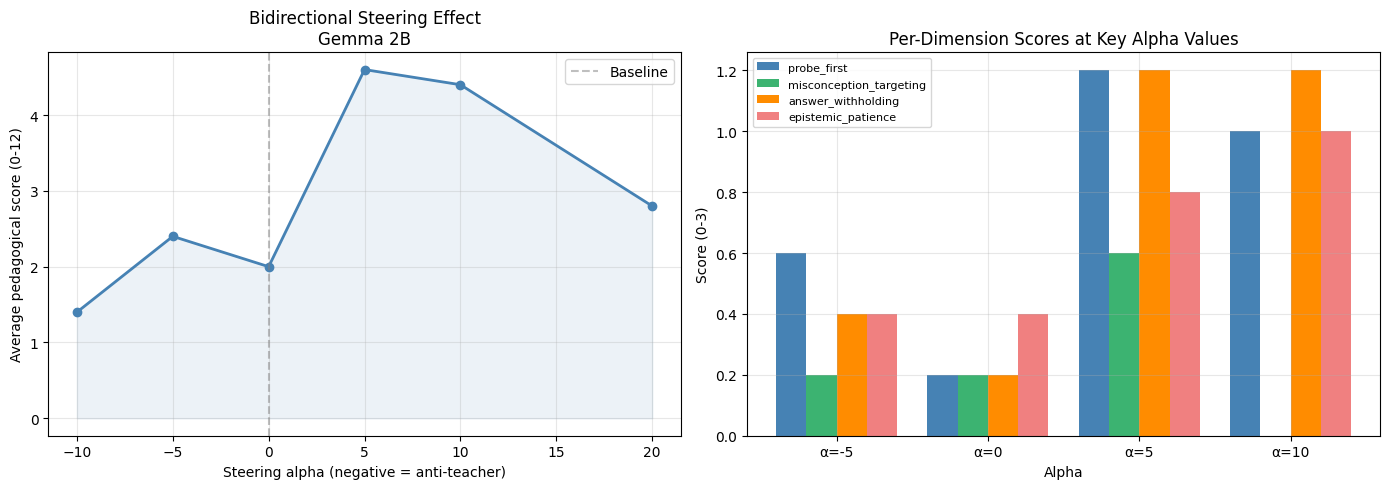


Baseline (α=0):      2.00/12
Best positive (α=5):  4.60/12
Best negative (α=-10): 1.40/12
Bidirectional effect: CONFIRMED


In [18]:
# Plot: total score vs alpha (shows bidirectional effect)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

totals = [np.mean([s["total"] for s in all_scores[a]]) for a in alphas]
axes[0].plot(alphas, totals, marker='o', linewidth=2, color='steelblue')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[0].fill_between(alphas, totals, alpha=0.1, color='steelblue')
axes[0].set_xlabel('Steering alpha (negative = anti-teacher)')
axes[0].set_ylabel('Average pedagogical score (0-12)')
axes[0].set_title('Bidirectional Steering Effect\nGemma 2B')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

dims = ["probe_first", "misconception_targeting", "answer_withholding", "epistemic_patience"]
key_alphas = [-5, 0, 5, 10]
x = np.arange(len(key_alphas)); w = 0.2
dim_colors = ['steelblue', 'mediumseagreen', 'darkorange', 'lightcoral']
for i, dim in enumerate(dims):
    vals = [np.mean([s[dim] for s in all_scores[a]]) for a in key_alphas]
    axes[1].bar(x + i*w, vals, w, label=dim, color=dim_colors[i])
axes[1].set_xlabel('Alpha'); axes[1].set_ylabel('Score (0-3)')
axes[1].set_title('Per-Dimension Scores at Key Alpha Values')
axes[1].set_xticks(x + w*1.5); axes[1].set_xticklabels([f'α={a}' for a in key_alphas])
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('steering_bidirectional.png', dpi=150, bbox_inches='tight')
plt.show()

baseline = np.mean([s["total"] for s in all_scores[0]])
best_pos = max([a for a in alphas if a > 0], key=lambda a: np.mean([s["total"] for s in all_scores[a]]))
best_neg = min([a for a in alphas if a < 0], key=lambda a: np.mean([s["total"] for s in all_scores[a]]))
print(f"\nBaseline (α=0):      {baseline:.2f}/12")
print(f"Best positive (α={best_pos}):  {np.mean([s['total'] for s in all_scores[best_pos]]):.2f}/12")
print(f"Best negative (α={best_neg}): {np.mean([s['total'] for s in all_scores[best_neg]]):.2f}/12")
bidir = np.mean([s['total'] for s in all_scores[best_neg]]) < baseline < np.mean([s['total'] for s in all_scores[best_pos]])
print(f"Bidirectional effect: {'CONFIRMED' if bidir else 'NOT confirmed'}")


## 7. Sub-Axis Decomposition
Split teacher prompts into three behavioral sub-categories and test whether they occupy distinct directions.


In [19]:
# Reload instruct for sub-axis
print("Reloading Gemma 2B instruct for sub-axis analysis...")
model_sub = HookedTransformer.from_pretrained("google/gemma-2-2b-it", device=device, dtype=torch.float16)
model_sub.eval()

withholding_prompts = [
    "A student asks for the answer to a homework problem before showing any work. What do you say?",
    "A student says 'just tell me how to solve this' without describing what they've tried. How do you respond?",
    "A student asks you to write their code for them. What's your first response?",
    "A student wants the solution to a debugging problem immediately. What do you do first?",
    "A student asks for the answer to a recursion problem and clearly hasn't attempted it. What do you do?",
    "A student is frustrated and wants you to just give them the answer. How do you respond?",
    "A student says 'this is too hard, just tell me.' What do you say?",
    "A student wants you to explain something they should figure out themselves. What do you do?",
    "A student says they've been trying for an hour. Should you just give them the answer?",
    "A student asks you to just give them the solution to the linked list problem on their exam.",
]
probing_prompts_sub = [
    "A student says they don't understand pointers. What's your first question?",
    "A student is stuck on a sorting algorithm. What do you ask before explaining?",
    "A student doesn't understand why their code isn't working. What do you do first?",
    "A student says 'I don't get Big O notation at all.' What's your opening move?",
    "A student is confused about the difference between a stack and a queue. How do you start?",
    "A student says they don't understand recursion. What's your first question to them?",
    "A student asks why their binary search isn't working. What do you ask first?",
    "A student is confused about pointers. What do you ask before explaining anything?",
    "A student doesn't understand dynamic programming. What's your first move?",
    "A student says 'I just don't get it.' What do you ask them first?",
]
misconception_prompts_sub = [
    "A student says '2+2=5, right?' How do you respond?",
    "A student claims that recursion always uses more memory than iteration. What do you say?",
    "A student thinks a linked list is faster than an array for random access. How do you address this?",
    "A student says merge sort is O(n) because it just splits the array. How do you respond?",
    "A student believes that == and .equals() always do the same thing in Java. How do you respond?",
    "A student says 'I already know this' before you've checked their understanding. What do you do?",
    "A student gets the right answer but for the wrong reason. What do you do?",
    "A student thinks debugging means running the code and seeing what happens. How do you guide them?",
    "A student says 'I just google the answer when I'm stuck.' How do you respond as their teacher?",
    "A student doesn't see why they need to understand time complexity. What do you say?",
]

print("Extracting sub-axis activations...")
w_acts = get_activations(model_sub, withholding_prompts, [best_layer_gemma])[best_layer_gemma]
p_acts = get_activations(model_sub, probing_prompts_sub, [best_layer_gemma])[best_layer_gemma]
m_acts = get_activations(model_sub, misconception_prompts_sub, [best_layer_gemma])[best_layer_gemma]
a_acts = get_activations(model_sub, assistant_prompts, [best_layer_gemma])[best_layer_gemma]

del model_sub; torch.cuda.empty_cache()

asst_mean = a_acts.mean(dim=0)
w_axis = (w_acts.mean(dim=0) - asst_mean); w_axis /= w_axis.norm()
p_axis = (p_acts.mean(dim=0) - asst_mean); p_axis /= p_axis.norm()
m_axis = (m_acts.mean(dim=0) - asst_mean); m_axis /= m_axis.norm()

sims_sub = {
    "Withholding vs Probing":        torch.dot(w_axis, p_axis).item(),
    "Withholding vs Misconception":  torch.dot(w_axis, m_axis).item(),
    "Probing vs Misconception":      torch.dot(p_axis, m_axis).item(),
}

print("\n=== SUB-AXIS PAIRWISE COSINE SIMILARITIES ===")
for pair, sim in sims_sub.items():
    print(f"  {pair}: {sim:.3f} -> {'DISTINCT' if abs(sim) < 0.7 else 'OVERLAPPING'}")

teacher_axis_cpu = results_gemma[best_layer_gemma]["teacher_axis"]
print("\n=== SUB-AXES vs OVERALL TEACHER AXIS ===")
print(f"  Withholding:    {torch.dot(w_axis, teacher_axis_cpu).item():.3f}")
print(f"  Probing:        {torch.dot(p_axis, teacher_axis_cpu).item():.3f}")
print(f"  Misconception:  {torch.dot(m_axis, teacher_axis_cpu).item():.3f}")


Reloading Gemma 2B instruct for sub-axis analysis...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b-it into HookedTransformer
Extracting sub-axis activations...
  0/10...
  0/10...
  0/10...
  0/30...
  20/30...

=== SUB-AXIS PAIRWISE COSINE SIMILARITIES ===
  Withholding vs Probing: 0.872 -> OVERLAPPING
  Withholding vs Misconception: 0.897 -> OVERLAPPING
  Probing vs Misconception: 0.789 -> OVERLAPPING

=== SUB-AXES vs OVERALL TEACHER AXIS ===
  Withholding:    0.963
  Probing:        0.892
  Misconception:  0.951


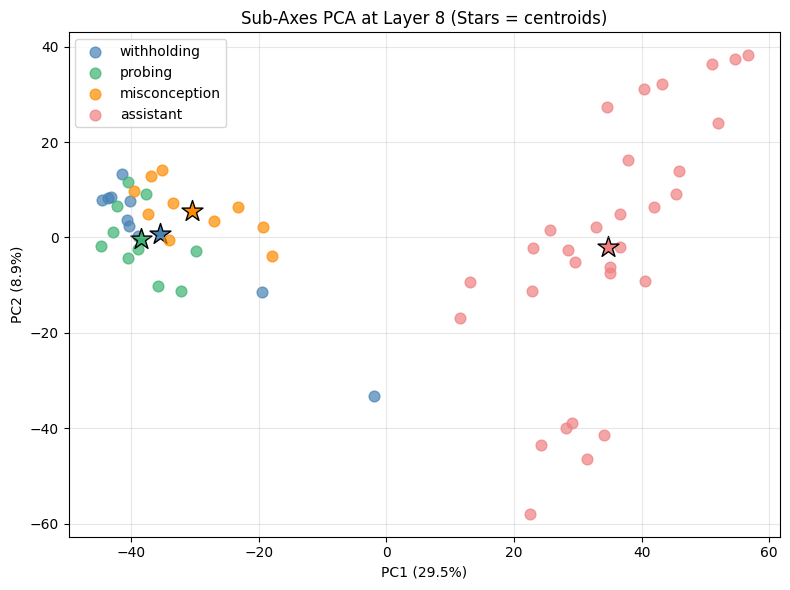

In [20]:
all_sub = torch.cat([w_acts, p_acts, m_acts, a_acts]).cpu().float().numpy()
sub_labels = ["withholding"]*10 + ["probing"]*10 + ["misconception"]*10 + ["assistant"]*len(assistant_prompts)
pca_sub = PCA(n_components=2); acts_sub_2d = pca_sub.fit_transform(all_sub)
colors_sub = {"withholding": "steelblue", "probing": "mediumseagreen", "misconception": "darkorange", "assistant": "lightcoral"}

plt.figure(figsize=(8, 6))
for label in colors_sub:
    mask = [l == label for l in sub_labels]; pts = acts_sub_2d[mask]
    plt.scatter(pts[:, 0], pts[:, 1], c=colors_sub[label], label=label, alpha=0.7, s=60)
    plt.scatter(pts[:, 0].mean(), pts[:, 1].mean(), c=colors_sub[label], s=250, marker="*", edgecolors="black", lw=1)
plt.xlabel(f"PC1 ({pca_sub.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_sub.explained_variance_ratio_[1]:.1%})")
plt.title(f"Sub-Axes PCA at Layer {best_layer_gemma} (Stars = centroids)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("sub_axes_pca.png", dpi=150, bbox_inches='tight')
plt.show()


## 8. Prompt Sensitivity Analysis
Is the Teacher Axis an artifact of our specific prompt wording?
We compute the axis from an entirely different set of prompts and measure cosine similarity to the original.
High similarity = axis is prompt-robust. Low similarity = axis is prompt-dependent.


=== PROMPT SENSITIVITY RESULT ===
Primary vs alternate Teacher Axis cosine similarity: 0.952
ROBUST: Teacher Axis is consistent across different prompt formulations.


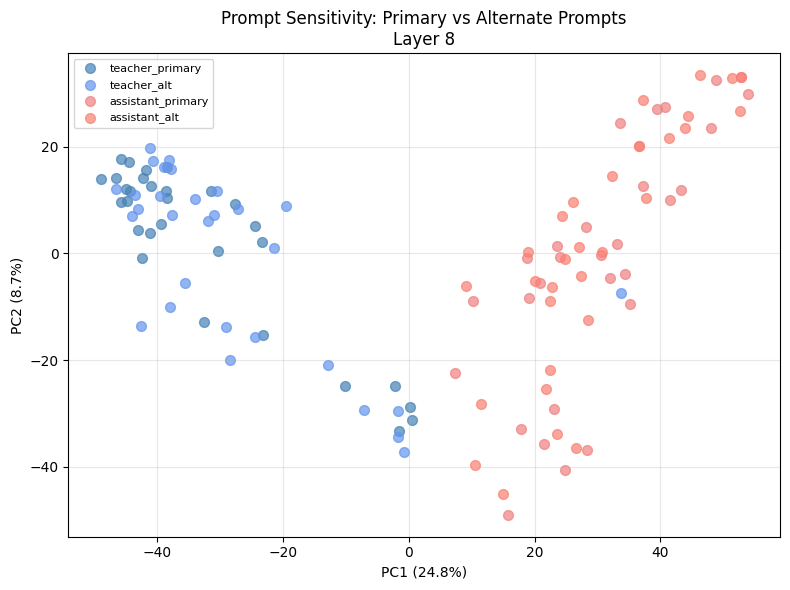

In [21]:
teacher_axis_alt = g_teacher_i_alt_cpu[best_layer_gemma].mean(dim=0) - g_asst_i_alt_cpu[best_layer_gemma].mean(dim=0)
teacher_axis_alt_norm = teacher_axis_alt / teacher_axis_alt.norm()

sensitivity_sim = torch.dot(teacher_axis_alt_norm, results_gemma[best_layer_gemma]["teacher_axis"]).item()

print(f"=== PROMPT SENSITIVITY RESULT ===")
print(f"Primary vs alternate Teacher Axis cosine similarity: {sensitivity_sim:.3f}")
if sensitivity_sim > 0.7:
    print("ROBUST: Teacher Axis is consistent across different prompt formulations.")
elif sensitivity_sim > 0.4:
    print("MODERATE: Some consistency but partially prompt-dependent.")
else:
    print("SENSITIVE: Axis varies with prompt choice — methodological concern.")

# PCA showing both prompt sets
all_sens = torch.cat([
    g_teacher_i_cpu[best_layer_gemma], g_teacher_i_alt_cpu[best_layer_gemma],
    g_asst_i_cpu[best_layer_gemma], g_asst_i_alt_cpu[best_layer_gemma],
]).numpy()
sens_labels = (["teacher_primary"]*len(teacher_prompts) + ["teacher_alt"]*len(teacher_prompts_alt) +
               ["assistant_primary"]*len(assistant_prompts) + ["assistant_alt"]*len(assistant_prompts_alt))
pca_s = PCA(n_components=2); acts_s = pca_s.fit_transform(all_sens)
colors_s = {"teacher_primary": "steelblue", "teacher_alt": "cornflowerblue",
            "assistant_primary": "lightcoral", "assistant_alt": "salmon"}
plt.figure(figsize=(8, 6))
for label in colors_s:
    mask = [l == label for l in sens_labels]; pts = acts_s[mask]
    plt.scatter(pts[:, 0], pts[:, 1], c=colors_s[label], label=label, alpha=0.7, s=50)
plt.xlabel(f"PC1 ({pca_s.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_s.explained_variance_ratio_[1]:.1%})")
plt.title(f"Prompt Sensitivity: Primary vs Alternate Prompts\nLayer {best_layer_gemma}")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("prompt_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()


## 9. Cross-Model Replication 1: Mistral 7B
Mistral 7B has a public base/instruct pair with no license approval required.


In [22]:
# Free Gemma cached activations to make room
del g_teacher_b, g_asst_b, g_neutral_b
gc.collect(); torch.cuda.empty_cache()
print(f"GPU available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.2f} GB")


GPU available: 17.05 GB


In [23]:
mistral_layers = [8, 12, 16, 20]

print("Loading Mistral 7B instruct...")
model = HookedTransformer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.1", device=device, dtype=torch.float16)
model.eval()

print("Extracting Mistral instruct activations...")
m_teacher_i  = get_activations(model, teacher_prompts, mistral_layers, batch_size=2)
m_asst_i     = get_activations(model, assistant_prompts, mistral_layers, batch_size=2)
m_neutral_i  = get_activations(model, neutral_prompts, mistral_layers, batch_size=2)

m_teacher_i_cpu = {l: v.cpu() for l, v in m_teacher_i.items()}
m_asst_i_cpu    = {l: v.cpu() for l, v in m_asst_i.items()}
m_neutral_i_cpu = {l: v.cpu() for l, v in m_neutral_i.items()}

del model, m_teacher_i, m_asst_i, m_neutral_i
torch.cuda.empty_cache()
print("Instruct done.")


Loading Mistral 7B instruct...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Loaded pretrained model mistralai/Mistral-7B-Instruct-v0.1 into HookedTransformer
Extracting Mistral instruct activations...
  0/30...
  20/30...
  0/30...
  20/30...
  0/10...
Instruct done.


In [24]:
print("Loading Mistral 7B base...")
model = HookedTransformer.from_pretrained("mistralai/Mistral-7B-v0.1", device=device, dtype=torch.float16)
model.eval()

m_teacher_b = get_activations(model, teacher_prompts, mistral_layers, batch_size=2)
m_asst_b    = get_activations(model, assistant_prompts, mistral_layers, batch_size=2)
m_neutral_b = get_activations(model, neutral_prompts, mistral_layers, batch_size=2)

del model; torch.cuda.empty_cache()
print("Base done.")

print("\nComputing Mistral axes...")
results_mistral = compute_axes(m_teacher_i_cpu, m_asst_i_cpu, m_neutral_i_cpu,
                                m_teacher_b, m_asst_b, m_neutral_b, mistral_layers)
best_layer_mistral = mistral_layers[np.argmin([results_mistral[l]["cosine_similarity"] for l in mistral_layers])]
print(f"Best layer: {best_layer_mistral}")


Loading Mistral 7B base...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Loaded pretrained model mistralai/Mistral-7B-v0.1 into HookedTransformer
  0/30...
  20/30...
  0/30...
  20/30...
  0/10...
Base done.

Computing Mistral axes...
  Layer 8: cosine_sim=-0.006, sep_base=1.3, sep_instruct=2.5
  Layer 12: cosine_sim=-0.094, sep_base=1.9, sep_instruct=4.1
  Layer 16: cosine_sim=0.076, sep_base=3.6, sep_instruct=6.6
  Layer 20: cosine_sim=0.033, sep_base=6.2, sep_instruct=10.6
Best layer: 12


## 10. Cross-Model Replication 2: Llama 3.1 8B
Requires Meta license approval at huggingface.co/meta-llama/Llama-3.1-8B


In [27]:
del m_teacher_b, m_asst_b, m_neutral_b
gc.collect(); torch.cuda.empty_cache()
print(f"GPU available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.2f} GB")


NameError: name 'm_teacher_b' is not defined

In [28]:
llama_layers = [8, 12, 16, 20]

print("Loading Llama 3.1 8B instruct...")
model = HookedTransformer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct", device=device, dtype=torch.float16)
model.eval()

print("Extracting Llama instruct activations...")
l_teacher_i  = get_activations(model, teacher_prompts, llama_layers, batch_size=2)
l_asst_i     = get_activations(model, assistant_prompts, llama_layers, batch_size=2)
l_neutral_i  = get_activations(model, neutral_prompts, llama_layers, batch_size=2)

l_teacher_i_cpu = {l: v.cpu() for l, v in l_teacher_i.items()}
l_asst_i_cpu    = {l: v.cpu() for l, v in l_asst_i.items()}
l_neutral_i_cpu = {l: v.cpu() for l, v in l_neutral_i.items()}

del model, l_teacher_i, l_asst_i, l_neutral_i
torch.cuda.empty_cache()
print("Instruct done.")


Loading Llama 3.1 8B instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer
Extracting Llama instruct activations...
  0/30...
  20/30...
  0/30...
  20/30...
  0/10...
Instruct done.


In [1]:
print("Loading Llama 3.1 8B base...")
model = HookedTransformer.from_pretrained("meta-llama/Llama-3.1-8B", device=device, dtype=torch.float16)
model.eval()

l_teacher_b = get_activations(model, teacher_prompts, llama_layers, batch_size=2)
l_asst_b    = get_activations(model, assistant_prompts, llama_layers, batch_size=2)
l_neutral_b = get_activations(model, neutral_prompts, llama_layers, batch_size=2)

del model; torch.cuda.empty_cache()
print("Base done.")

print("\nComputing Llama axes...")
results_llama = compute_axes(l_teacher_i_cpu, l_asst_i_cpu, l_neutral_i_cpu,
                              l_teacher_b, l_asst_b, l_neutral_b, llama_layers)
best_layer_llama = llama_layers[np.argmin([results_llama[l]["cosine_similarity"] for l in llama_layers])]
print(f"Best layer: {best_layer_llama}")


Loading Llama 3.1 8B base...


NameError: name 'HookedTransformer' is not defined

## 11. Cross-Model Comparison

NameError: name 'results_llama' is not defined

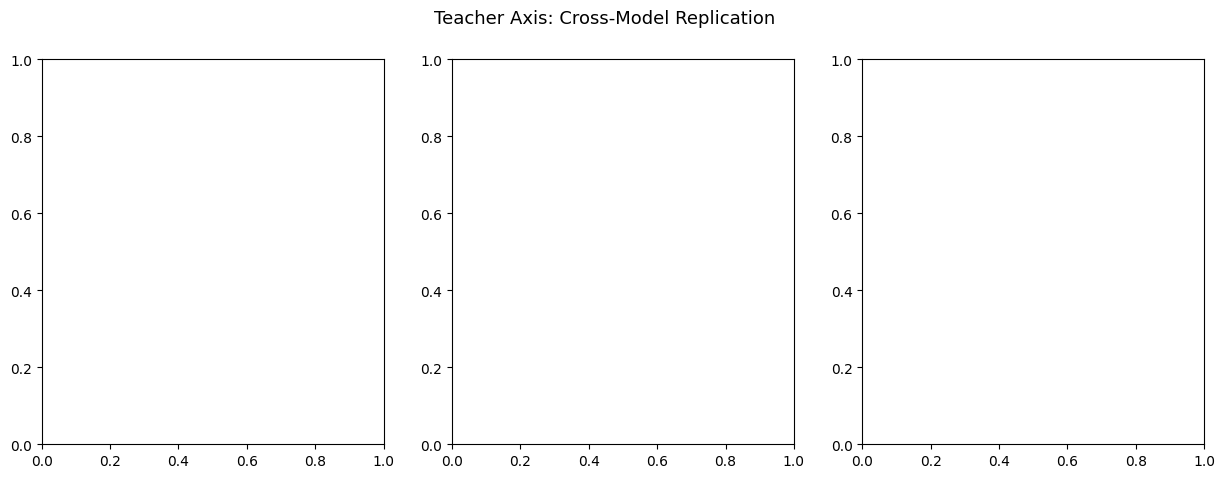

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Teacher Axis: Cross-Model Replication", fontsize=13)

model_results = [
    ("Gemma 2B", results_gemma, gemma_layers, 'steelblue'),
    ("Mistral 7B", results_mistral, mistral_layers, 'mediumseagreen'),
    ("Llama 3.1 8B", results_llama, llama_layers, 'darkorange'),
]

for ax, (name, res, layers_list, color) in zip(axes, model_results):
    cosines = [res[l]["cosine_similarity"] for l in layers_list]
    ax.plot(layers_list, cosines, marker='o', linewidth=2, color=color)
    ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Threshold')
    ax.axhline(y=-0.7, color='red', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.set_xlabel('Layer'); ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'{name}\nTeacher vs Assistant Axis')
    ax.set_ylim(-1, 1); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cross_model_replication.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== REPLICATION SUMMARY ===")
print(f"{'Model':<18} {'Layers distinct':>16} {'Replicated?':>12}")
print("-" * 48)
for name, res, layers_list, _ in model_results:
    n_distinct = sum(1 for l in layers_list if abs(res[l]["cosine_similarity"]) < 0.7)
    print(f"{name:<18} {n_distinct}/{len(layers_list):>14} {'YES' if n_distinct >= 3 else 'NO':>12}")


## 12. Final Summary

In [2]:
print("=" * 65)
print("COMPLETE EXPERIMENT SUMMARY")
print("=" * 65)

print("\n1. TEACHER AXIS DISTINCTNESS (Gemma 2B)")
for layer in gemma_layers:
    sim = results_gemma[layer]["cosine_similarity"]
    print(f"   Layer {layer}: {sim:.3f} -> {'DISTINCT' if abs(sim) < 0.7 else 'OVERLAPPING'}")

print("\n2. RLHF SEPARATION EFFECT (Gemma 2B)")
for layer in gemma_layers:
    print(f"   Layer {layer}: base={results_gemma[layer]['separation_base']:.1f}, instruct={results_gemma[layer]['separation_instruct']:.1f}")

print("\n3. STEERING EFFECT (Gemma 2B)")
baseline = np.mean([s["total"] for s in all_scores[0]])
best_pos = max([a for a in alphas if a > 0], key=lambda a: np.mean([s["total"] for s in all_scores[a]]))
best_neg = min([a for a in alphas if a < 0], key=lambda a: np.mean([s["total"] for s in all_scores[a]]))
print(f"   Baseline:       {baseline:.2f}/12")
print(f"   Best pos (α={best_pos}): {np.mean([s['total'] for s in all_scores[best_pos]]):.2f}/12")
print(f"   Best neg (α={best_neg}): {np.mean([s['total'] for s in all_scores[best_neg]]):.2f}/12")

print("\n4. SUB-AXIS DECOMPOSITION")
for pair, sim in sims_sub.items():
    print(f"   {pair}: {sim:.3f} -> {'DISTINCT' if abs(sim) < 0.7 else 'OVERLAPPING (holistic direction)'}")

print("\n5. PROMPT SENSITIVITY")
print(f"   Primary vs alternate axis similarity: {sensitivity_sim:.3f} -> {'ROBUST' if sensitivity_sim > 0.7 else 'MODERATE' if sensitivity_sim > 0.4 else 'SENSITIVE'}")

print("\n6. CROSS-MODEL REPLICATION")
for name, res, layers_list, _ in model_results:
    n = sum(1 for l in layers_list if abs(res[l]["cosine_similarity"]) < 0.7)
    print(f"   {name}: {n}/{len(layers_list)} layers distinct -> {'REPLICATED' if n >= 3 else 'NOT replicated'}")


COMPLETE EXPERIMENT SUMMARY

1. TEACHER AXIS DISTINCTNESS (Gemma 2B)


NameError: name 'gemma_layers' is not defined